# 0.4 Capas de destino del ABM (OSM)

Descarga las capas de destino que consume el simulador (notebooks 4 y 5), una por
cada propósito de viaje de la EOD:

| Propósito EOD | Capa | Fuente | Tags OSM |
|---|---|---|---|
| `compras_tramites` | comercio | OSM | `shop=*` + `amenity` (pharmacy, bank, marketplace, post_office) |
| `social_recreacion` | áreas verdes | OSM | `leisure` (park, garden, playground…) + `landuse` (grass…) |
| `salud` | establecimientos | MINSAL (**no OSM**) | se filtra aparte, ver sección 3 |

Replica el procesamiento de áreas verdes del antiguo `3.1 geometry_correction`
(explode → filtro área ≥ 250 m² → punto representativo).

**Entrada:** `data/raw/aoi_{zona}.gpkg` (nb 0)

**Salidas:**
- `data/raw/comercio_{zona}.gpkg`
- `data/raw/areas_verdes_{zona}.gpkg`
- `data/processed/destinations/verdes_points_{zona}.gpkg`

---

In [3]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))
from config import (ZONA, COMUNAS, FP_AOI, CRS_GEO, CRS_PROJ,
                    FP_COMERCIO, FP_VERDES_RAW, FP_VERDES_PTS, FP_SALUD)

import geopandas as gpd
import pandas as pd
import osmnx as ox

aoi = gpd.read_file(FP_AOI, layer='aoi').to_crs(CRS_GEO)
polygon = aoi.geometry.iloc[0]
print(f'Zona: {ZONA} | AOI cargado')

Zona: suroriente | AOI cargado


## 1. Comercio (propósito `compras_tramites`)

Todos los `shop=*` más algunos `amenity` de trámites frecuentes. OSM devuelve
puntos y a veces polígonos (locales grandes); estos últimos se reducen a su punto
representativo para tener una capa homogénea de puntos.

In [4]:
tags_comercio = {
    'shop': True,
    'amenity': ['pharmacy', 'bank', 'marketplace', 'post_office'],
}

# osmnx 1.4.x: geometries_from_polygon (en 2.x sería ox.features.features_from_polygon)
com = ox.geometries_from_polygon(polygon, tags=tags_comercio)
com = com[com.geometry.notna() & ~com.geometry.is_empty].copy()

# Homogeneizar a puntos (los polígonos → punto representativo)
es_poly = com.geom_type.isin(['Polygon', 'MultiPolygon'])
com.loc[es_poly, 'geometry'] = com.loc[es_poly].to_crs(CRS_PROJ).representative_point().to_crs(CRS_GEO)
com = com[com.geom_type == 'Point'].copy()

# Quedarse con columnas útiles y estables
cols_keep = [c for c in ['name', 'shop', 'amenity', 'brand', 'geometry'] if c in com.columns]
com = com[cols_keep].reset_index(drop=True).to_crs(CRS_PROJ)
com['dest_id'] = [f'com_{i}' for i in range(len(com))]

print(f'Comercio: {len(com)} puntos')
print(com[[c for c in ["shop", "amenity"] if c in com.columns]].apply(lambda s: s.value_counts().head(3)))
com.to_file(FP_COMERCIO, driver='GPKG')
print(f'Guardado: {FP_COMERCIO}')

C:\Users\mbell\anaconda3\envs\ox\Lib\site-packages\pandas\core\frame.py:717: DeprecationWarning: Passing a BlockManager to GeoDataFrame is deprecated and will raise in a future version. Use public APIs instead.
  warnings.warn(
C:\Users\mbell\anaconda3\envs\ox\Lib\site-packages\pandas\core\frame.py:717: DeprecationWarning: Passing a BlockManager to GeoDataFrame is deprecated and will raise in a future version. Use public APIs instead.
  warnings.warn(
C:\Users\mbell\anaconda3\envs\ox\Lib\site-packages\pandas\core\frame.py:717: DeprecationWarning: Passing a BlockManager to GeoDataFrame is deprecated and will raise in a future version. Use public APIs instead.
  warnings.warn(
C:\Users\mbell\anaconda3\envs\ox\Lib\site-packages\pandas\core\frame.py:717: DeprecationWarning: Passing a BlockManager to GeoDataFrame is deprecated and will raise in a future version. Use public APIs instead.
  warnings.warn(
C:\Users\mbell\anaconda3\envs\ox\Lib\site-packages\pandas\core\frame.py:717: Deprecation

Comercio: 2517 puntos
              shop  amenity
alcohol      156.0      NaN
bank           NaN    100.0
convenience  313.0      NaN
pharmacy       NaN    210.0
post_office    NaN     28.0
yes          157.0      NaN
Guardado: C:\Users\mbell\Desktop\UNIVERSIDAD\DOCTORADO\TESIS\REPOSITORIOS\simulador-am-tesis\data\raw\comercio_suroriente.gpkg


## 2. Áreas verdes (propósito `social_recreacion`)

Polígonos de OSM (`leisure` + `landuse`) → mismo procesamiento que el antiguo
`3.1 geometry_correction`: explode, filtro de área mínima y punto representativo.

In [5]:
AREA_MIN_M2 = 250  # mismo umbral que 3.1

tags_verdes = {
    'leisure': ['park', 'garden', 'playground', 'pitch',
                'recreation_ground', 'dog_park', 'common'],
    'landuse': ['grass', 'recreation_ground', 'village_green'],
}

# osmnx 1.4.x: geometries_from_polygon (en 2.x sería ox.features.features_from_polygon)
verdes = ox.geometries_from_polygon(polygon, tags=tags_verdes).to_crs(CRS_PROJ)
verdes = verdes[verdes.geom_type.isin(['Polygon', 'MultiPolygon'])].copy()

# Guardar capa de polígonos disuelta (equivalente a areas_verdes_penalolen.gpkg)
verdes_dis = gpd.GeoDataFrame(
    {'id': [ZONA]}, geometry=[verdes.geometry.unary_union], crs=CRS_PROJ)
verdes_dis.to_file(FP_VERDES_RAW, driver='GPKG')
print(f'Áreas verdes (polígono disuelto) guardado: {FP_VERDES_RAW}')

C:\Users\mbell\anaconda3\envs\ox\Lib\site-packages\pandas\core\frame.py:717: DeprecationWarning: Passing a BlockManager to GeoDataFrame is deprecated and will raise in a future version. Use public APIs instead.
  warnings.warn(
C:\Users\mbell\anaconda3\envs\ox\Lib\site-packages\pandas\core\frame.py:717: DeprecationWarning: Passing a BlockManager to GeoDataFrame is deprecated and will raise in a future version. Use public APIs instead.
  warnings.warn(
C:\Users\mbell\anaconda3\envs\ox\Lib\site-packages\pandas\core\frame.py:717: DeprecationWarning: Passing a BlockManager to GeoDataFrame is deprecated and will raise in a future version. Use public APIs instead.
  warnings.warn(
C:\Users\mbell\anaconda3\envs\ox\Lib\site-packages\pandas\core\frame.py:717: DeprecationWarning: Passing a BlockManager to GeoDataFrame is deprecated and will raise in a future version. Use public APIs instead.
  warnings.warn(
C:\Users\mbell\anaconda3\envs\ox\Lib\site-packages\pandas\core\frame.py:717: Deprecation

Áreas verdes (polígono disuelto) guardado: C:\Users\mbell\Desktop\UNIVERSIDAD\DOCTORADO\TESIS\REPOSITORIOS\simulador-am-tesis\data\raw\areas_verdes_suroriente.gpkg


C:\Users\mbell\anaconda3\envs\ox\Lib\site-packages\pandas\core\frame.py:717: DeprecationWarning: Passing a BlockManager to GeoDataFrame is deprecated and will raise in a future version. Use public APIs instead.
  warnings.warn(
C:\Users\mbell\anaconda3\envs\ox\Lib\site-packages\pandas\core\frame.py:717: DeprecationWarning: Passing a BlockManager to GeoDataFrame is deprecated and will raise in a future version. Use public APIs instead.
  warnings.warn(
C:\Users\mbell\anaconda3\envs\ox\Lib\site-packages\pandas\core\frame.py:717: DeprecationWarning: Passing a BlockManager to GeoDataFrame is deprecated and will raise in a future version. Use public APIs instead.
  warnings.warn(


In [6]:
# Explode → filtro área → punto representativo (lógica idéntica a 3.1)
vp = verdes_dis.explode(index_parts=False).reset_index(drop=True)
vp = vp[vp.geometry.notna() & ~vp.geometry.is_empty].copy()
vp = vp[vp.geom_type == 'Polygon'].copy()
vp['area_m2'] = vp.geometry.area
vp = vp[vp['area_m2'] >= AREA_MIN_M2].copy()

vp['geometry'] = vp.representative_point()
vp = vp.reset_index(drop=True)
vp['dest_id'] = [f'verde_{i}' for i in range(len(vp))]
verdes_points = vp[['dest_id', 'area_m2', 'geometry']].copy()

print(f'Puntos de áreas verdes: {len(verdes_points)} (área ≥ {AREA_MIN_M2} m²)')
FP_VERDES_PTS.parent.mkdir(parents=True, exist_ok=True)
verdes_points.to_file(FP_VERDES_PTS, driver='GPKG')
print(f'Guardado: {FP_VERDES_PTS}')

Puntos de áreas verdes: 2938 (área ≥ 250 m²)


C:\Users\mbell\anaconda3\envs\ox\Lib\site-packages\pandas\core\frame.py:717: DeprecationWarning: Passing a BlockManager to GeoDataFrame is deprecated and will raise in a future version. Use public APIs instead.
  warnings.warn(
C:\Users\mbell\anaconda3\envs\ox\Lib\site-packages\pandas\core\frame.py:717: DeprecationWarning: Passing a BlockManager to GeoDataFrame is deprecated and will raise in a future version. Use public APIs instead.
  warnings.warn(
C:\Users\mbell\anaconda3\envs\ox\Lib\site-packages\pandas\core\frame.py:717: DeprecationWarning: Passing a BlockManager to GeoDataFrame is deprecated and will raise in a future version. Use public APIs instead.
  warnings.warn(
C:\Users\mbell\anaconda3\envs\ox\Lib\site-packages\pandas\core\frame.py:717: DeprecationWarning: Passing a BlockManager to GeoDataFrame is deprecated and will raise in a future version. Use public APIs instead.
  warnings.warn(
C:\Users\mbell\anaconda3\envs\ox\Lib\site-packages\pandas\core\frame.py:717: Deprecation

Guardado: C:\Users\mbell\Desktop\UNIVERSIDAD\DOCTORADO\TESIS\REPOSITORIOS\simulador-am-tesis\data\processed\destinations\verdes_points_suroriente.gpkg


## 3. Salud (MINSAL — no OSM)

La capa de salud no viene de OSM sino del registro MINSAL de establecimientos.
Ya tienes `establecimientos_salud_suroriente.gpkg` con 169 puntos y campo
`CUT_COMUNA`, así que basta filtrarla a las comunas de la zona activa.

Si más adelante escalas a Gran Santiago, reemplaza el archivo de origen por el
registro MINSAL de toda la RM y este mismo filtro por `CUT_COMUNA` funcionará.

In [7]:
# Origen: el gpkg regional que ya tienes (suroriente cubre las 5 comunas del piloto)
FP_SALUD_ORIGEN = FP_SALUD.parent / 'establecimientos_salud_suroriente.gpkg'

salud = gpd.read_file(FP_SALUD_ORIGEN)
salud_zona = salud[salud['CUT_COMUNA'].astype(int).isin(COMUNAS)].copy()

print(f'Salud: {len(salud)} en origen → {len(salud_zona)} en la zona')
print(salud_zona.groupby('NOM_COMUNA').size().to_string())

if FP_SALUD_ORIGEN.resolve() != FP_SALUD.resolve():
    salud_zona.to_file(FP_SALUD, driver='GPKG')
    print(f'Guardado: {FP_SALUD}')

Salud: 169 en origen → 129 en la zona
NOM_COMUNA
LA FLORIDA    43
LA REINA      10
MACUL         15
PEÑALOLÉN     28
ÑUÑOA         33


C:\Users\mbell\anaconda3\envs\ox\Lib\site-packages\pandas\core\frame.py:717: DeprecationWarning: Passing a BlockManager to GeoDataFrame is deprecated and will raise in a future version. Use public APIs instead.
  warnings.warn(
C:\Users\mbell\anaconda3\envs\ox\Lib\site-packages\pandas\core\frame.py:717: DeprecationWarning: Passing a BlockManager to GeoDataFrame is deprecated and will raise in a future version. Use public APIs instead.
  warnings.warn(


## 4. Vista conjunta de destinos

C:\Users\mbell\anaconda3\envs\ox\Lib\site-packages\pandas\core\frame.py:717: DeprecationWarning: Passing a BlockManager to GeoDataFrame is deprecated and will raise in a future version. Use public APIs instead.
  warnings.warn(
C:\Users\mbell\anaconda3\envs\ox\Lib\site-packages\pandas\core\frame.py:717: DeprecationWarning: Passing a BlockManager to GeoDataFrame is deprecated and will raise in a future version. Use public APIs instead.
  warnings.warn(
C:\Users\mbell\anaconda3\envs\ox\Lib\site-packages\pandas\core\frame.py:717: DeprecationWarning: Passing a BlockManager to GeoDataFrame is deprecated and will raise in a future version. Use public APIs instead.
  warnings.warn(
C:\Users\mbell\anaconda3\envs\ox\Lib\site-packages\pandas\core\frame.py:717: DeprecationWarning: Passing a BlockManager to GeoDataFrame is deprecated and will raise in a future version. Use public APIs instead.
  warnings.warn(
C:\Users\mbell\anaconda3\envs\ox\Lib\site-packages\pandas\core\frame.py:717: Deprecation

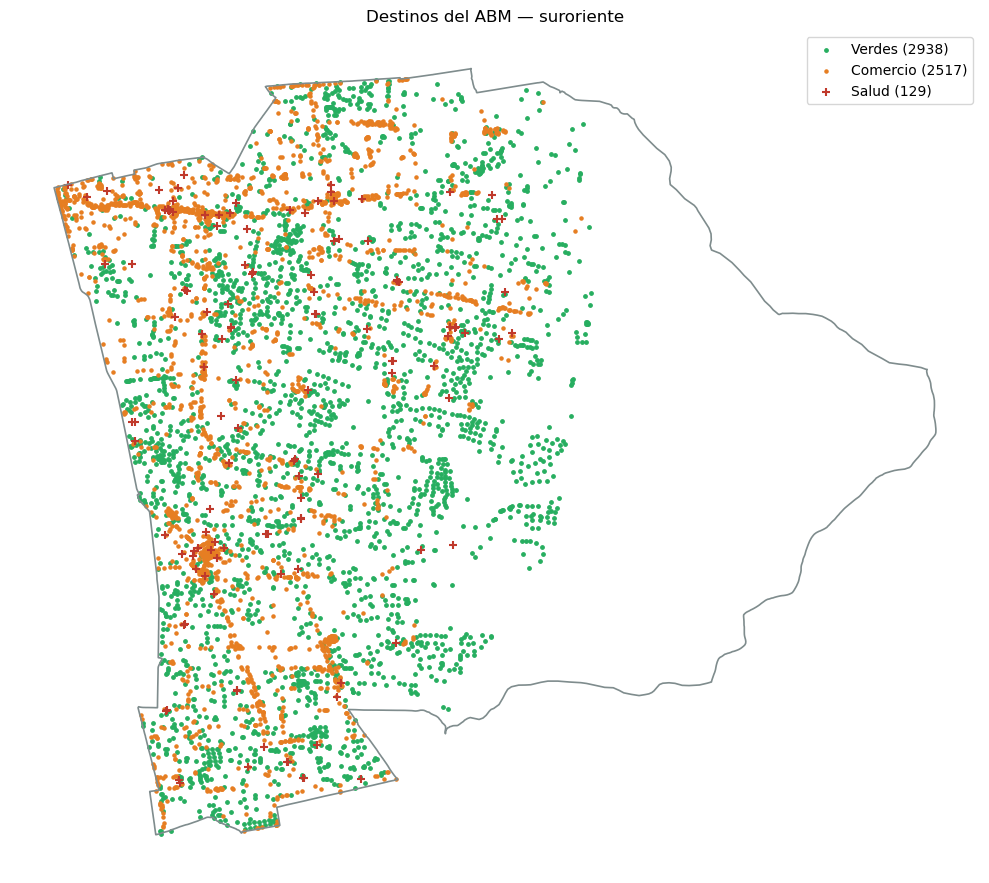

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))
aoi.to_crs(CRS_PROJ).boundary.plot(ax=ax, color='#7f8c8d', linewidth=1.2)
verdes_points.plot(ax=ax, color='#27ae60', markersize=6, label=f'Verdes ({len(verdes_points)})')
com.plot(ax=ax, color='#e67e22', markersize=5, label=f'Comercio ({len(com)})')
salud_zona.to_crs(CRS_PROJ).plot(ax=ax, color='#c0392b', markersize=40,
                                 marker='+', label=f'Salud ({len(salud_zona)})')
ax.legend()
ax.set_title(f'Destinos del ABM — {ZONA}')
ax.set_axis_off()
plt.tight_layout()
plt.show()